In [29]:
import pandas as pd

In [30]:
df = pd.read_csv("student_performance.csv")

In [31]:
df.head()

,Student_ID,Name,Gender,Age,Math,Science,English,Attendance
0,1,Amit,Male,20,78,85,72,90
1,2,Jyoti,Female,21,92,88,95,96
2,3,Sumit,Male,20,65,70,68,82
3,4,Priya,Female,21,55,62,58,75
4,5,Rahul,Male,22,88,91,84,94


In [32]:
df.shape

(15, 8)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student_ID  15 non-null     int64 
 1   Name        15 non-null     object
 2   Gender      15 non-null     object
 3   Age         15 non-null     int64 
 4   Math        15 non-null     int64 
 5   Science     15 non-null     int64 
 6   English     15 non-null     int64 
 7   Attendance  15 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 1.1+ KB


In [34]:
df.isnull().sum()

Student_ID    0
Name          0
Gender        0
Age           0
Math          0
Science       0
English       0
Attendance    0
dtype: int64

In [35]:
#Calculate Total Marks
df["Total_Marks"] = df["Math"] + df["Science"] + df["English"]
print(df) 

    Student_ID    Name  Gender  Age  Math  Science  English  Attendance  \
0            1    Amit    Male   20    78       85       72          90   
1            2   Jyoti  Female   21    92       88       95          96   
2            3   Sumit    Male   20    65       70       68          82   
3            4   Priya  Female   21    55       62       58          75   
4            5   Rahul    Male   22    88       91       84          94   
5            6    Neha  Female   20    74       79       81          89   
6            7   Rohan    Male   21    61       66       59          78   
7            8  Anjali  Female   22    95       93       97          98   
8            9   Vikas    Male   20    69       72       75          84   
9           10   Pooja  Female   21    82       86       80          91   
10          11   Akash    Male   22    48       55       51          68   
11          12   Sneha  Female   20    87       90       89          93   
12          13   Karan   

In [36]:
#Calculate Average Marks
df["Average_marks"] = (df["Math"] + df["Science"] + df["English"])/3
print(df)

    Student_ID    Name  Gender  Age  Math  Science  English  Attendance  \
0            1    Amit    Male   20    78       85       72          90   
1            2   Jyoti  Female   21    92       88       95          96   
2            3   Sumit    Male   20    65       70       68          82   
3            4   Priya  Female   21    55       62       58          75   
4            5   Rahul    Male   22    88       91       84          94   
5            6    Neha  Female   20    74       79       81          89   
6            7   Rohan    Male   21    61       66       59          78   
7            8  Anjali  Female   22    95       93       97          98   
8            9   Vikas    Male   20    69       72       75          84   
9           10   Pooja  Female   21    82       86       80          91   
10          11   Akash    Male   22    48       55       51          68   
11          12   Sneha  Female   20    87       90       89          93   
12          13   Karan   

In [37]:
#Find the highest scorer
highest_average=max(df["Average_marks"])
highest_score=df[df["Average_marks"]== highest_average]
print(highest_score)

   Student_ID    Name  Gender  Age  Math  Science  English  Attendance  \
7           8  Anjali  Female   22    95       93       97          98   

   Total_Marks  Average_marks  
7          285           95.0  


In [38]:
#Find the lowest scorer.
lowest_average = min(df["Average_marks"])
lowest_score=df[df["Average_marks"]==lowest_average]
print(lowest_score)

    Student_ID   Name Gender  Age  Math  Science  English  Attendance  \
10          11  Akash   Male   22    48       55       51          68   

    Total_Marks  Average_marks  
10          154      51.333333  


In [39]:
#Create a Pass/Fail column
df["Result"] = df["Average_marks"].apply(
    lambda x: "pass" if x >= 40 else "Fail"
)
print(df[["Name","Average_marks","Result"]])

      Name  Average_marks Result
0     Amit      78.333333   pass
1    Jyoti      91.666667   pass
2    Sumit      67.666667   pass
3    Priya      58.333333   pass
4    Rahul      87.666667   pass
5     Neha      78.000000   pass
6    Rohan      62.000000   pass
7   Anjali      95.000000   pass
8    Vikas      72.000000   pass
9    Pooja      82.666667   pass
10   Akash      51.333333   pass
11   Sneha      88.666667   pass
12   Karan      72.666667   pass
13   Meera      91.666667   pass
14   Arjun      61.000000   pass


In [40]:
#Find students with Average > 75
students_above_75 = df[df["Average_marks"] > 75]

print(students_above_75[["Name", "Average_marks"]])

      Name  Average_marks
0     Amit      78.333333
1    Jyoti      91.666667
4    Rahul      87.666667
5     Neha      78.000000
7   Anjali      95.000000
9    Pooja      82.666667
11   Sneha      88.666667
13   Meera      91.666667


In [41]:
#Who has the highest average marks?
highest_avg = max(df["Average_marks"])

print(df[df["Average_marks"] == highest_avg][["Name", "Average_marks"]])

     Name  Average_marks
7  Anjali           95.0


In [42]:
#Which subject has the highest average marks?
math_avg = df["Math"].mean()
science_avg = df["Science"].mean()
english_avg = df["English"].mean()

print(math_avg)
print(science_avg)
print(english_avg)
max(math_avg,science_avg,english_avg)

74.4
77.53333333333333
75.8


np.float64(77.53333333333333)

In [51]:
#How many students passed and how many students failed?
print(df["Result"].value_counts())

Result
pass    15
Name: count, dtype: int64


In [46]:
#How many students passed?
sum(df["Result"] == "pass")

15

In [47]:
#Does higher attendance appear to be associated with higher average marks?
print(df[["Name","Attendance","Average_marks"]])

      Name  Attendance  Average_marks
0     Amit          90      78.333333
1    Jyoti          96      91.666667
2    Sumit          82      67.666667
3    Priya          75      58.333333
4    Rahul          94      87.666667
5     Neha          89      78.000000
6    Rohan          78      62.000000
7   Anjali          98      95.000000
8    Vikas          84      72.000000
9    Pooja          91      82.666667
10   Akash          68      51.333333
11   Sneha          93      88.666667
12   Karan          86      72.666667
13   Meera          97      91.666667
14   Arjun          72      61.000000


Higher attendance generally appears to be associated with higher average marks, although the relationship is not consistent for every student.

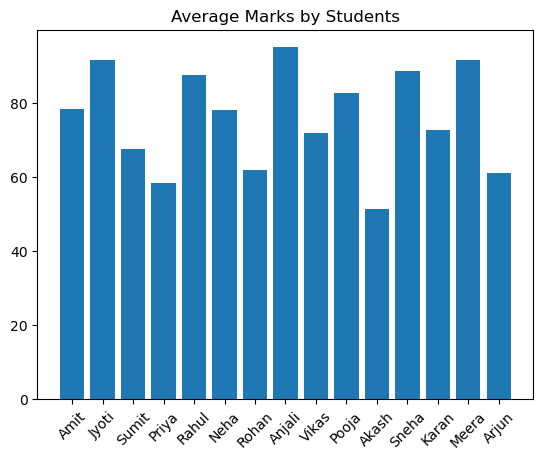

In [48]:
#Average Marks by Student
import matplotlib.pyplot as plt
plt.bar(df["Name"],df["Average_marks"])
plt.title("Average Marks by Students")
plt.xticks(rotation=45)
plt.show()

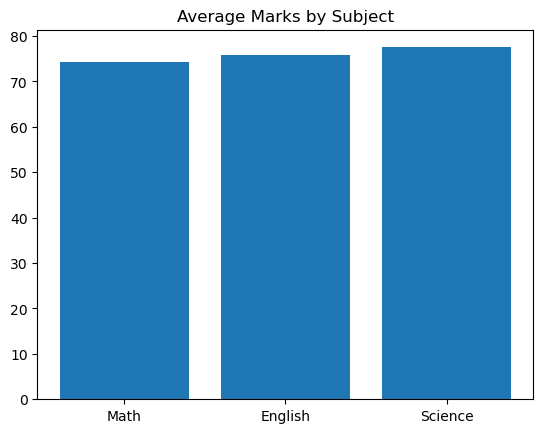

In [49]:
#Average Marks by Subject
import matplotlib.pyplot as plt
subjects = ["Math","English","Science"]
averages = [math_avg,english_avg,science_avg]
plt.bar(subjects,averages)
plt.title("Average Marks by Subject")
plt.show()

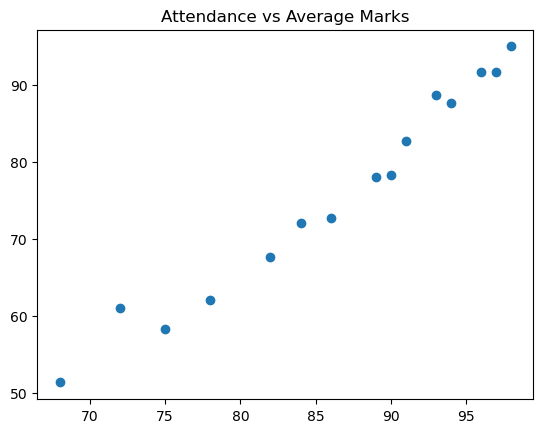

In [50]:
#Attendance vs Average Marks
import matplotlib.pyplot as plt
plt.scatter(df["Attendance"],df["Average_marks"])
plt.title("Attendance vs Average Marks")
plt.show()

Project Insights
- Anjali achieved the highest average score of 95.0.
- Science had the highest subject average of approximately 77.53.
- All 15 students passed the defined pass criteria.
- Higher attendance generally appears to be associated with better average marks, although this is not consistent for every student.
- Overall, the dataset shows good student performance.